<a href="https://colab.research.google.com/github/mts924/Backtest-Python-NVIDIA/blob/main/backtest_python_RUSSEL2000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

        SMA 50/200  Buy & hold
CAGR         0.038       0.093
Vol          0.168       0.237
Sharpe       0.307       0.495
MaxDD       -0.495      -0.586
Calmar       0.077       0.159
Time in market: 70% | Trades: 35


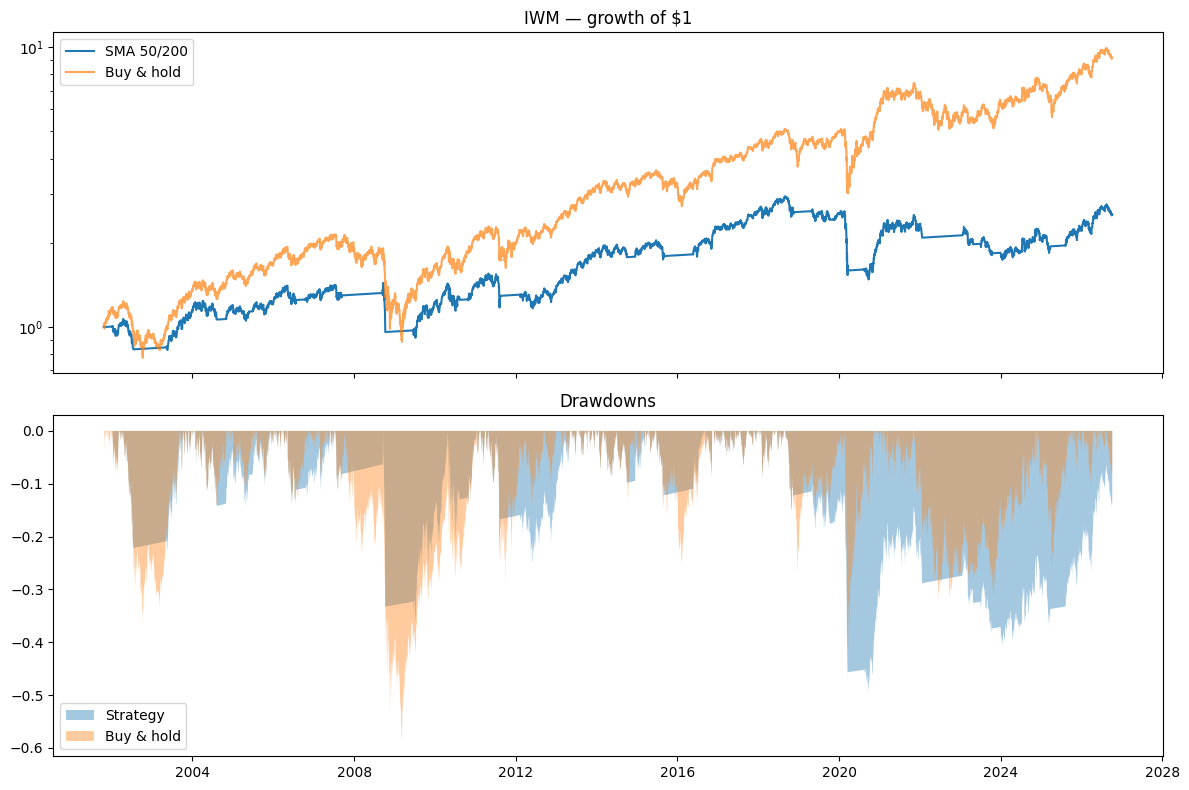


Sharpe by (fast rows, slow cols):
       100   150   200   250
10   0.46  0.49  0.48  0.53
20   0.33  0.42  0.45  0.47
50   0.45  0.30  0.31  0.37
100   NaN  0.27  0.26  0.35


In [ ]:
# pip install yfinance pandas numpy matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# ---------- Parameters ----------
TICKER, START = "IWM", "2001-01-01"   # or "^RUT" for the index
FAST, SLOW = 50, 200
COST_BPS = 5          # one-way cost per trade
CASH_RATE = 0.02      # annual yield when in cash
TD = 252

# ---------- Data ----------
raw = yf.download(TICKER, start=START, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
px = raw["Close"].dropna()

# ---------- Backtest ----------
def backtest(price, fast, slow, cost_bps=COST_BPS, cash_rate=CASH_RATE):
    df = pd.DataFrame({"price": price})
    df["fast"] = df["price"].rolling(fast).mean()
    df["slow"] = df["price"].rolling(slow).mean()
    df["signal"] = (df["fast"] > df["slow"]).astype(int)
    df["pos"] = df["signal"].shift(1).fillna(0)          # trade next day: no look-ahead
    df["ret"] = df["price"].pct_change().fillna(0)
    cash_d = (1 + cash_rate) ** (1 / TD) - 1
    cost = df["pos"].diff().abs().fillna(0) * cost_bps / 1e4
    df["strat"] = df["pos"] * df["ret"] + (1 - df["pos"]) * cash_d - cost
    df = df.loc[df["slow"].first_valid_index():].copy()
    df["strat_eq"] = (1 + df["strat"]).cumprod()
    df["bh_eq"] = (1 + df["ret"]).cumprod()
    return df

def metrics(r):
    eq = (1 + r).cumprod()
    cagr = eq.iloc[-1] ** (TD / len(r)) - 1
    vol = r.std() * np.sqrt(TD)
    mdd = (eq / eq.cummax() - 1).min()
    return {"CAGR": cagr, "Vol": vol, "Sharpe": r.mean() / r.std() * np.sqrt(TD),
            "MaxDD": mdd, "Calmar": cagr / abs(mdd)}

bt = backtest(px, FAST, SLOW)
res = pd.DataFrame({f"SMA {FAST}/{SLOW}": metrics(bt["strat"]),
                    "Buy & hold": metrics(bt["ret"])})
print(res.round(3))
print(f"Time in market: {bt['pos'].mean():.0%} | Trades: {int(bt['pos'].diff().abs().sum())}")

# ---------- Charts ----------
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(bt["strat_eq"], label=f"SMA {FAST}/{SLOW}")
ax[0].plot(bt["bh_eq"], label="Buy & hold", alpha=0.7)
ax[0].set_yscale("log"); ax[0].set_title(f"{TICKER} — growth of $1"); ax[0].legend()
for col, lab in [("strat_eq", "Strategy"), ("bh_eq", "Buy & hold")]:
    dd = bt[col] / bt[col].cummax() - 1
    ax[1].fill_between(dd.index, dd, 0, alpha=0.4, label=lab)
ax[1].set_title("Drawdowns"); ax[1].legend()
plt.tight_layout(); plt.show()

# ---------- Parameter sensitivity (Sharpe) ----------
grid = pd.DataFrame({s: {f: metrics(backtest(px, f, s)["strat"])["Sharpe"] if f < s else np.nan
                         for f in [10, 20, 50, 100]} for s in [100, 150, 200, 250]})
print("\nSharpe by (fast rows, slow cols):\n", grid.round(2))

Period: 2001-10-31 -> 2026-10-05

                      CAGR    Vol Sharpe   MaxDD Calmar In market Trades
IWM SMA 50/200        3.8%  16.8%   0.31  -49.5%   0.08     69.8%     35
    SMA 20/100        4.4%  15.6%   0.35  -36.9%   0.12     67.6%     92
    Price > SMA 200   5.7%  14.9%   0.45  -27.3%   0.21     69.7%    221
    Faber 10-month    6.6%  16.0%   0.48  -34.7%   0.19     70.9%     49
    Buy & hold        9.4%  23.7%   0.50  -58.6%   0.16    100.0%      0
SPY SMA 50/200        9.4%  13.2%   0.74  -33.7%   0.28     75.9%     25
    SMA 20/100        7.2%  11.9%   0.65  -21.6%   0.33     74.1%     67
    Price > SMA 200   8.1%  11.3%   0.74  -20.7%   0.39     77.0%    165
    Faber 10-month    8.7%  12.1%   0.75  -24.6%   0.36     77.6%     37
    Buy & hold       10.3%  18.9%   0.61  -55.2%   0.19    100.0%      0


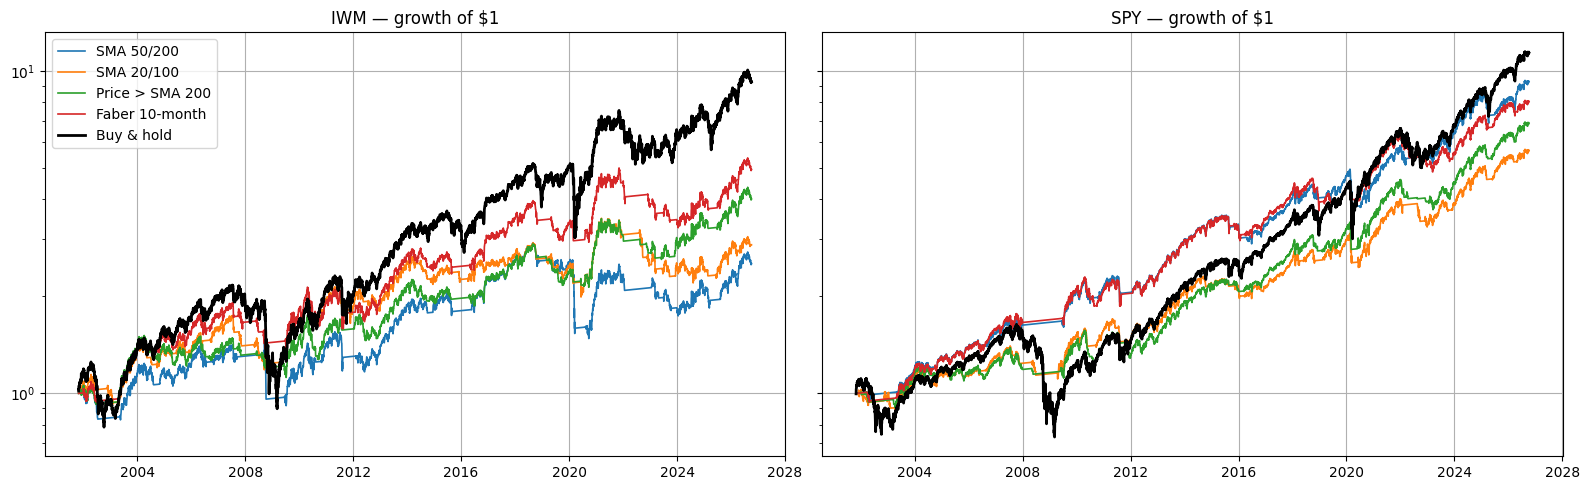

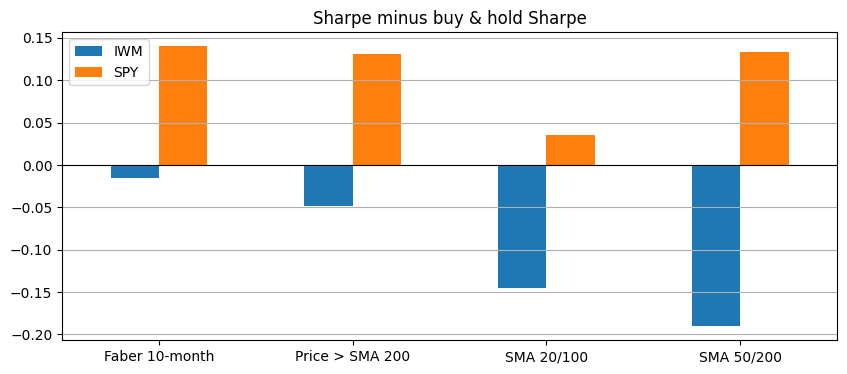

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

TICKERS = ["IWM", "SPY"]
COST_BPS, CASH_RATE, TD = 5, 0.02, 252

data = yf.download(TICKERS, start="2001-01-01", auto_adjust=True, progress=False)["Close"].dropna()

# ---------- Signals (1 = long, 0 = cash, NaN = warm-up) ----------
def signals(p):
    sma = lambda n: p.rolling(n).mean()
    cross = lambda f, s: (sma(f) > sma(s)).astype(float).where(sma(s).notna())
    # Faber: check once a month, close vs 10-month SMA, hold until next month-end
    me = p.groupby(p.index.to_period("M")).tail(1)          # last trading day of each month
    sma10m = me.rolling(10).mean()
    faber = (me > sma10m).astype(float).where(sma10m.notna()).reindex(p.index).ffill()
    return {
        "SMA 50/200":       cross(50, 200),
        "SMA 20/100":       cross(20, 100),
        "Price > SMA 200":  (p > sma(200)).astype(float).where(sma(200).notna()),
        "Faber 10-month":   faber,
        "Buy & hold":       pd.Series(1.0, index=p.index),
    }

def run(p, sig):
    pos = sig.fillna(0).shift(1).fillna(0)                   # trade next day: no look-ahead
    ret = p.pct_change().fillna(0)
    cash_d = (1 + CASH_RATE) ** (1 / TD) - 1
    cost = pos.diff().abs().fillna(0) * COST_BPS / 1e4
    return pos * ret + (1 - pos) * cash_d - cost, pos

def metrics(r, pos):
    eq = (1 + r).cumprod()
    cagr = eq.iloc[-1] ** (TD / len(r)) - 1
    mdd = (eq / eq.cummax() - 1).min()
    return {"CAGR": cagr, "Vol": r.std() * np.sqrt(TD),
            "Sharpe": r.mean() / r.std() * np.sqrt(TD),
            "MaxDD": mdd, "Calmar": cagr / abs(mdd),
            "In market": pos.mean(), "Trades": int(pos.diff().abs().sum())}

# ---------- Run everything on a common window ----------
rows, curves = {}, {}
for t in TICKERS:
    p = data[t].dropna()
    sigs = signals(p)
    start = max(s.first_valid_index() for s in sigs.values())   # same period for every rule
    curves[t] = {}
    for name, sig in sigs.items():
        r, pos = run(p, sig)
        r, pos = r.loc[start:], pos.loc[start:]
        rows[(t, name)] = metrics(r, pos)
        curves[t][name] = (1 + r).cumprod()

table = pd.DataFrame(rows).T
fmt = {c: "{:.1%}" for c in ["CAGR", "Vol", "MaxDD", "In market"]} | {"Sharpe": "{:.2f}", "Calmar": "{:.2f}", "Trades": "{:.0f}"}
print(f"Period: {start.date()} -> {data.index[-1].date()}\n")
print(table.apply(lambda col: col.map(fmt[col.name].format)).to_string())

# ---------- Charts ----------
fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 5), sharey=True)
for ax, t in zip(axes, TICKERS):
    for name, eq in curves[t].items():
        ax.plot(eq, label=name, lw=2 if name == "Buy & hold" else 1.2,
                color="black" if name == "Buy & hold" else None)
    ax.set_yscale("log"); ax.set_title(f"{t} — growth of $1"); ax.grid(True)
axes[0].legend()
plt.tight_layout(); plt.show()

# Sharpe gap vs buy & hold: does trend-following work better on large caps?
gap = table["Sharpe"].unstack(0)
gap = gap.drop("Buy & hold") - gap.loc["Buy & hold"]
gap.plot(kind="bar", figsize=(10, 4), title="Sharpe minus buy & hold Sharpe", rot=0)
plt.axhline(0, color="black", lw=0.8); plt.grid(True, axis="y"); plt.show()

/tmp/ipykernel_2154/294740014.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  irx = yf.download("^IRX", start="2001-01-01", progress=False)["Close"]


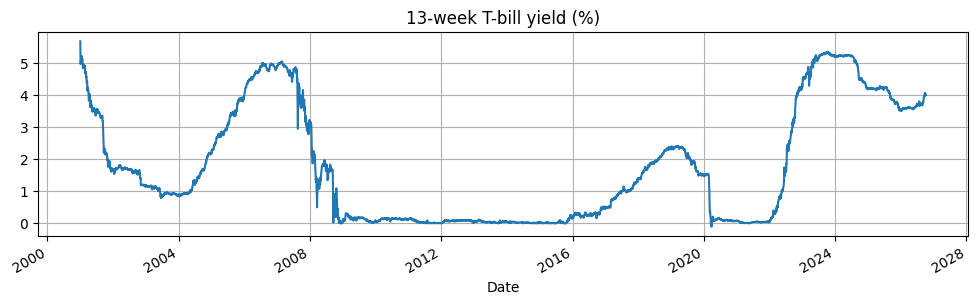


=== Sharpe ===
Period                  Full 2001–2011 2012–today
Ticker Rule                                      
IWM    SMA 50/200       0.20      0.12       0.26
       SMA 20/100       0.24      0.33       0.17
       Price > SMA 200  0.33      0.24       0.39
       Faber 10-month   0.37      0.30       0.43
       Buy & hold       0.43      0.32       0.52
SPY    SMA 50/200       0.61      0.49       0.67
       SMA 20/100       0.50      0.21       0.69
       Price > SMA 200  0.58      0.10       0.89
       Faber 10-month   0.60      0.48       0.68
       Buy & hold       0.52      0.19       0.84

=== CAGR ===
Period                   Full 2001–2011 2012–today
Ticker Rule                                       
IWM    SMA 50/200        3.7%      2.4%       4.6%
       SMA 20/100        4.3%      6.0%       3.1%
       Price > SMA 200   5.6%      4.4%       6.5%
       Faber 10-month    6.5%      5.6%       7.2%
       Buy & hold        9.4%      7.1%      11.0%
SPY    SMA 50

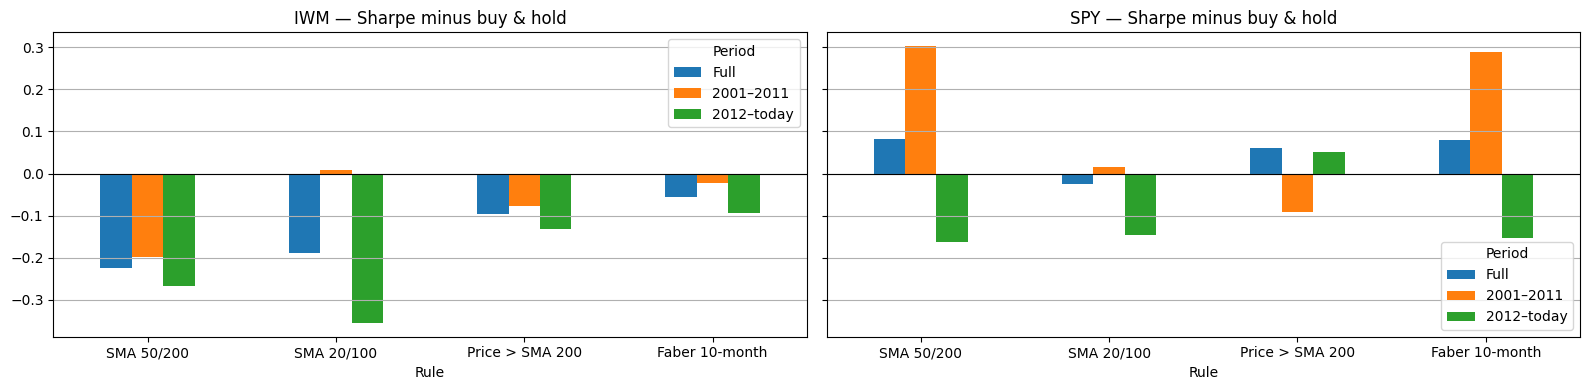

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

TICKERS = ["IWM", "SPY"]
COST_BPS, TD = 5, 252
PERIODS = {"Full": (None, None), "2001–2011": (None, "2011-12-31"), "2012–today": ("2012-01-01", None)}

data = yf.download(TICKERS, start="2001-01-01", auto_adjust=True, progress=False)["Close"].dropna()

# ---------- Real cash rate: 13-week T-bill yield (^IRX, in % per year) ----------
irx = yf.download("^IRX", start="2001-01-01", progress=False)["Close"]
if isinstance(irx, pd.DataFrame):
    irx = irx.iloc[:, 0]
irx = irx.reindex(data.index).ffill().bfill()          # bond market holidays differ from equities
rf_daily = ((1 + irx / 100) ** (1 / TD) - 1).shift(1).fillna(0)   # yesterday's quoted rate earned today

ax = irx.plot(figsize=(12, 3), title="13-week T-bill yield (%)"); ax.grid(True); plt.show()

# ---------- Signals (1 = long, 0 = cash, NaN = warm-up) ----------
def signals(p):
    sma = lambda n: p.rolling(n).mean()
    cross = lambda f, s: (sma(f) > sma(s)).astype(float).where(sma(s).notna())
    me = p.groupby(p.index.to_period("M")).tail(1)
    sma10m = me.rolling(10).mean()
    faber = (me > sma10m).astype(float).where(sma10m.notna()).reindex(p.index).ffill()
    return {
        "SMA 50/200":      cross(50, 200),
        "SMA 20/100":      cross(20, 100),
        "Price > SMA 200": (p > sma(200)).astype(float).where(sma(200).notna()),
        "Faber 10-month":  faber,
        "Buy & hold":      pd.Series(1.0, index=p.index),
    }

def run(p, sig, rf):
    pos = sig.fillna(0).shift(1).fillna(0)                 # trade next day: no look-ahead
    ret = p.pct_change().fillna(0)
    cost = pos.diff().abs().fillna(0) * COST_BPS / 1e4
    return pos * ret + (1 - pos) * rf - cost, pos

def metrics(r, pos, rf):
    eq = (1 + r).cumprod()
    cagr = eq.iloc[-1] ** (TD / len(r)) - 1
    mdd = (eq / eq.cummax() - 1).min()
    ex = r - rf                                            # Sharpe on excess return over T-bills
    return {"CAGR": cagr, "Vol": r.std() * np.sqrt(TD),
            "Sharpe": ex.mean() / r.std() * np.sqrt(TD),
            "MaxDD": mdd, "Calmar": cagr / abs(mdd),
            "In market": pos.mean(), "Trades": int(pos.diff().abs().sum())}

# ---------- Run once on the full history, then slice into periods ----------
rows = {}
for t in TICKERS:
    p = data[t].dropna()
    rf = rf_daily.reindex(p.index).fillna(0)
    sigs = signals(p)
    start = max(s.first_valid_index() for s in sigs.values())
    for name, sig in sigs.items():
        r, pos = run(p, sig, rf)
        for per, (a, b) in PERIODS.items():
            a = max(pd.Timestamp(a), start) if a else start
            sl = slice(a, b)
            rows[(per, t, name)] = metrics(r.loc[sl], pos.loc[sl], rf.loc[sl])

res = pd.DataFrame(rows).T
res.index.names = ["Period", "Ticker", "Rule"]
RULES = list(sigs)                                          # keep the original rule order

def show(metric, f):
    tab = res[metric].unstack("Period")[list(PERIODS)]
    tab = tab.reindex(pd.MultiIndex.from_product([TICKERS, RULES], names=["Ticker", "Rule"]))
    print(f"\n=== {metric} ===")
    print(tab.map(f.format).to_string())

show("Sharpe", "{:.2f}")
show("CAGR", "{:.1%}")
show("MaxDD", "{:.1%}")
show("Calmar", "{:.2f}")

# ---------- Sharpe advantage over buy & hold, by period ----------
fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 4), sharey=True)
for ax, t in zip(axes, TICKERS):
    s = res["Sharpe"].xs(t, level="Ticker").unstack("Period")[list(PERIODS)].reindex(RULES)
    (s.drop("Buy & hold") - s.loc["Buy & hold"]).plot(kind="bar", ax=ax, rot=0)
    ax.axhline(0, color="black", lw=0.8); ax.grid(True, axis="y")
    ax.set_title(f"{t} — Sharpe minus buy & hold")
plt.tight_layout(); plt.show()



/tmp/ipykernel_2950/2537056114.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  irx = yf.download("^IRX", start="2001-01-01", progress=False)["Close"]


=== Out-of-sample scorecard (rule chosen on 2001–2011, tested once on 2012–today) ===
Ticker                              IWM         SPY
Chosen rule (train)          Monthly 6m  Monthly 8m
Train Sharpe                       0.44        0.66
Test Sharpe                        0.21        0.79
B&H train Sharpe                   0.27        0.15
B&H test Sharpe                    0.52        0.84
Test CAGR                          3.7%       11.1%
B&H test CAGR                     10.9%       15.2%
Test MaxDD                       -34.2%      -24.3%
B&H test MaxDD                   -41.1%      -33.7%
Rank of chosen rule on test       26/28        8/28
Train/test rank corr.              0.02       -0.11

=== IWM: top 5 rules on TRAIN, and how they did on TEST ===
              Train Sharpe  Test Sharpe  Test CAGR  Test MaxDD
Monthly 6m           0.439        0.211      0.037      -0.342
Cross 10/300         0.421        0.381      0.064      -0.304
Cross 20/300         0.417        0.241 

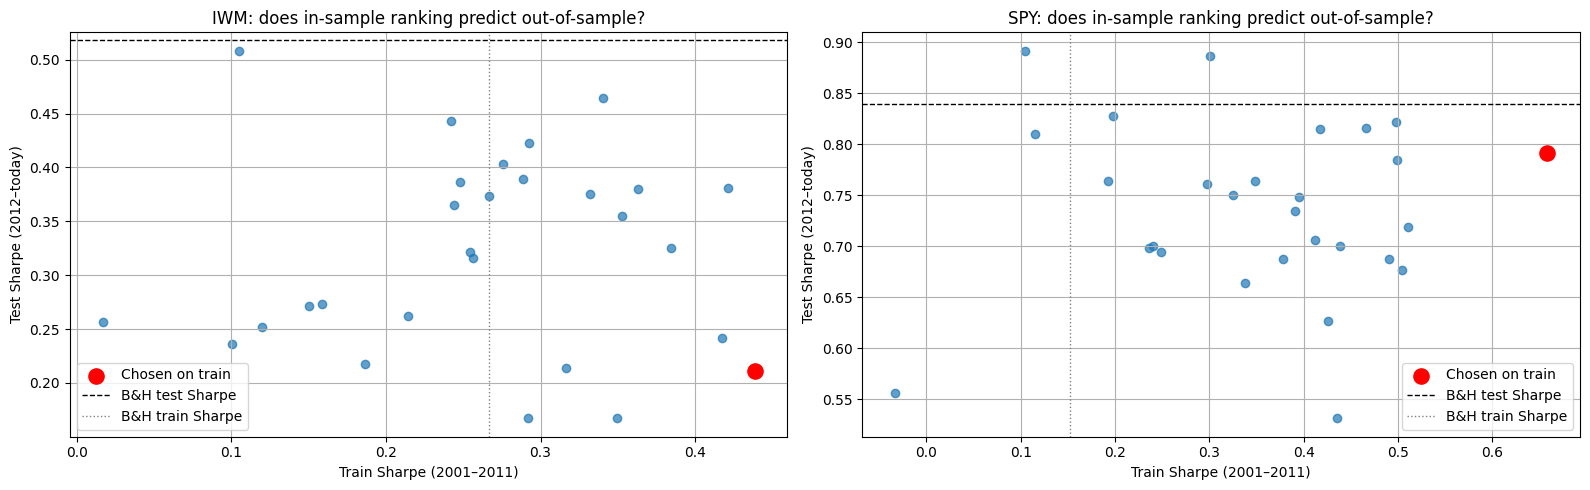

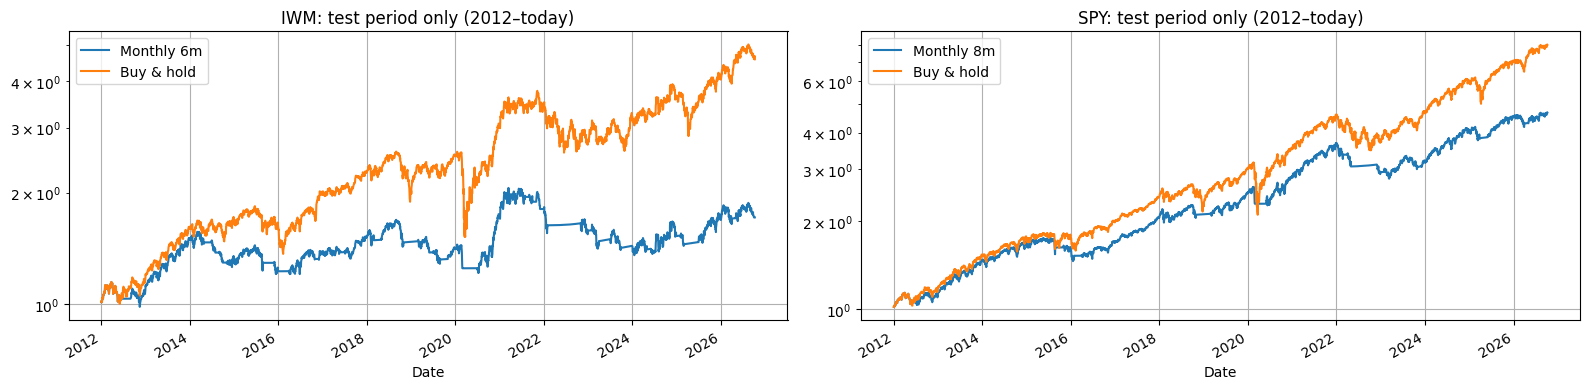

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

TICKERS = ["IWM", "SPY"]
COST_BPS, TD = 5, 252
TRAIN_END, TEST_START = "2011-12-31", "2012-01-01"     # tune on 2001–2011, score once on 2012–today

data = yf.download(TICKERS, start="2001-01-01", auto_adjust=True, progress=False)["Close"].dropna()
irx = yf.download("^IRX", start="2001-01-01", progress=False)["Close"]
if isinstance(irx, pd.DataFrame):
    irx = irx.iloc[:, 0]
irx = irx.reindex(data.index).ffill().bfill()
rf_daily = ((1 + irx / 100) ** (1 / TD) - 1).shift(1).fillna(0)

# ---------- Candidate rules (the "parameter space" we search on the training data) ----------
def candidates(p):
    sma = lambda n: p.rolling(n).mean()
    out = {}
    for f in [10, 20, 50, 100]:
        for s in [100, 150, 200, 250, 300]:
            if f < s:
                out[f"Cross {f}/{s}"] = (sma(f) > sma(s)).astype(float).where(sma(s).notna())
    for n in [50, 100, 150, 200, 250]:
        out[f"Price > SMA {n}"] = (p > sma(n)).astype(float).where(sma(n).notna())
    me = p.groupby(p.index.to_period("M")).tail(1)
    for m in [6, 8, 10, 12]:
        sm = me.rolling(m).mean()
        out[f"Monthly {m}m"] = (me > sm).astype(float).where(sm.notna()).reindex(p.index).ffill()
    return out

def run(p, sig, rf):
    pos = sig.fillna(0).shift(1).fillna(0)               # signals only use past prices: no look-ahead
    ret = p.pct_change().fillna(0)
    cost = pos.diff().abs().fillna(0) * COST_BPS / 1e4
    return pos * ret + (1 - pos) * rf - cost

def sharpe(r, rf):
    return (r - rf).mean() / r.std() * np.sqrt(TD)

def cagr(r):
    return (1 + r).prod() ** (TD / len(r)) - 1

def maxdd(r):
    eq = (1 + r).cumprod()
    return (eq / eq.cummax() - 1).min()

# ---------- 1) Tune on train only, 2) score the winner once on test ----------
results, summary, test_curves = {}, [], {}
for t in TICKERS:
    p = data[t].dropna()
    rf = rf_daily.reindex(p.index).fillna(0)
    cands = candidates(p)
    start = max(s.first_valid_index() for s in cands.values())
    tr, te = slice(start, TRAIN_END), slice(TEST_START, None)

    rows = {}
    for name, sig in cands.items():
        r = run(p, sig, rf)
        rows[name] = {"Train Sharpe": sharpe(r[tr], rf[tr]), "Test Sharpe": sharpe(r[te], rf[te]),
                      "Test CAGR": cagr(r[te]), "Test MaxDD": maxdd(r[te])}
    df = pd.DataFrame(rows).T.sort_values("Train Sharpe", ascending=False)
    results[t] = df

    bh = p.pct_change().fillna(0)
    best = df.index[0]                                  # chosen using TRAIN data only
    summary.append({
        "Ticker": t, "Chosen rule (train)": best,
        "Train Sharpe": df.loc[best, "Train Sharpe"], "Test Sharpe": df.loc[best, "Test Sharpe"],
        "B&H train Sharpe": sharpe(bh[tr], rf[tr]), "B&H test Sharpe": sharpe(bh[te], rf[te]),
        "Test CAGR": df.loc[best, "Test CAGR"], "B&H test CAGR": cagr(bh[te]),
        "Test MaxDD": df.loc[best, "Test MaxDD"], "B&H test MaxDD": maxdd(bh[te]),
        "Rank of chosen rule on test": f"{int(df['Test Sharpe'].rank(ascending=False)[best])}/{len(df)}",
        "Train/test rank corr.": df["Train Sharpe"].rank().corr(df["Test Sharpe"].rank()),
    })
    test_curves[t] = pd.DataFrame({best: (1 + run(p, cands[best], rf)[te]).cumprod(),
                                   "Buy & hold": (1 + bh[te]).cumprod()})

summary = pd.DataFrame(summary).set_index("Ticker")
shown = summary.copy()
for c in shown.columns:
    if "Sharpe" in c or "corr" in c:
        shown[c] = shown[c].map("{:.2f}".format)
    elif "CAGR" in c or "MaxDD" in c:
        shown[c] = shown[c].map("{:.1%}".format)
print("=== Out-of-sample scorecard (rule chosen on 2001–2011, tested once on 2012–today) ===")
print(shown.T.to_string())

for t in TICKERS:
    print(f"\n=== {t}: top 5 rules on TRAIN, and how they did on TEST ===")
    print(results[t].head(5).round(3).to_string())

# ---------- Charts ----------
fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 5))
for ax, t in zip(axes, TICKERS):
    df = results[t]
    ax.scatter(df["Train Sharpe"], df["Test Sharpe"], alpha=0.7)
    ax.scatter(df["Train Sharpe"].iloc[0], df["Test Sharpe"].iloc[0], color="red", s=120, label="Chosen on train")
    ax.axhline(summary.loc[t, "B&H test Sharpe"], color="black", ls="--", lw=1, label="B&H test Sharpe")
    ax.axvline(summary.loc[t, "B&H train Sharpe"], color="grey", ls=":", lw=1, label="B&H train Sharpe")
    ax.set_xlabel("Train Sharpe (2001–2011)"); ax.set_ylabel("Test Sharpe (2012–today)")
    ax.set_title(f"{t}: does in-sample ranking predict out-of-sample?"); ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(TICKERS), figsize=(16, 4))
for ax, t in zip(axes, TICKERS):
    test_curves[t].plot(ax=ax, logy=True, title=f"{t}: test period only (2012–today)")
    ax.grid(True)
plt.tight_layout(); plt.show()